In [12]:
!pip install imbalanced-learn

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import SMOTE

In [14]:
df = pd.read_csv("hiresafe_ml_dataset.csv")

df.head()

,industry,country,layoff_count,workforce_percentage,total_funding_million_usd,stock_price_change_7d,revenue_growth_percent,market_cap_billion_usd,ai_automation_flag,year,hiring_status,company_size_encoded
0,Finance,USA,86,8.15,1560.48,-3.99,-8.75,298.47,0,2023,Hiring,0
1,Finance,Singapore,26,14.01,290.02,-4.28,6.20,325.48,0,2020,Hiring,1
2,Finance,Germany,213,8.09,370.89,4.60,-34.19,152.19,0,2022,Hiring,2
3,Retail,Singapore,350,21.47,802.72,-9.14,8.33,23.43,0,2024,Slowdown,1
4,Tech,UK,410,21.06,1186.87,0.01,-12.26,23.32,1,2024,Hiring,1


In [15]:
def assign_status(row):

    if row["workforce_percentage"] > 18:
        return "Slowdown"

    elif row["workforce_percentage"] > 8:
        return "Freeze"

    elif row["revenue_growth_percent"] > 2:
        return "Hiring"

    else:
        return "Freeze"

df["hiring_status"] = df.apply(assign_status, axis=1)

# Remove leakage feature
df = df.drop(columns=["workforce_percentage"])

In [16]:
df["layoff_intensity"] = df["layoff_count"] / (df["market_cap_billion_usd"] + 1)

df["financial_stress"] = (
    -df["revenue_growth_percent"] +
    abs(df["stock_price_change_7d"])
)

df["funding_strength"] = (
    df["total_funding_million_usd"] /
    (df["market_cap_billion_usd"] + 1)
)

In [17]:
df = pd.get_dummies(df, columns=["industry", "country"], drop_first=True)

In [18]:
X = df.drop("hiring_status", axis=1)
y = df["hiring_status"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

hiring_status
Freeze      6682
Slowdown    6682
Hiring      6682
Name: count, dtype: int64


In [21]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=14,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=14,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=400, random_state=42)

In [22]:
# get predictions first
y_pred = model.predict(X_test)

# get probabilities
probs = model.predict_proba(X_test)
classes = model.classes_

# find index of Slowdown class
slowdown_index = list(classes).index("Slowdown")

# probability of slowdown
slowdown_prob = probs[:, slowdown_index]

# convert to 0-100 risk score
risk_score = slowdown_prob * 100

risk_df = pd.DataFrame({
    "Actual_Status": y_test.values,
    "Predicted_Status": y_pred,
    "Risk_Score": risk_score.round(2)
})

risk_df.head()

,Actual_Status,Predicted_Status,Risk_Score
0,Slowdown,Slowdown,83.52
1,Freeze,Freeze,20.18
2,Slowdown,Slowdown,96.04
3,Slowdown,Slowdown,62.43
4,Freeze,Freeze,2.95


In [23]:
def risk_level(score):

    if score < 35:
        return "Low Risk"

    elif score < 65:
        return "Moderate Risk"

    else:
        return "High Risk"

risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(risk_level)

risk_df.head(10)

,Actual_Status,Predicted_Status,Risk_Score,Risk_Level
0,Slowdown,Slowdown,83.52,High Risk
1,Freeze,Freeze,20.18,Low Risk
2,Slowdown,Slowdown,96.04,High Risk
3,Slowdown,Slowdown,62.43,Moderate Risk
4,Freeze,Freeze,2.95,Low Risk
5,Slowdown,Slowdown,59.78,Moderate Risk
6,Freeze,Freeze,30.06,Low Risk
7,Slowdown,Slowdown,90.35,High Risk
8,Slowdown,Slowdown,96.06,High Risk
9,Slowdown,Slowdown,94.54,High Risk


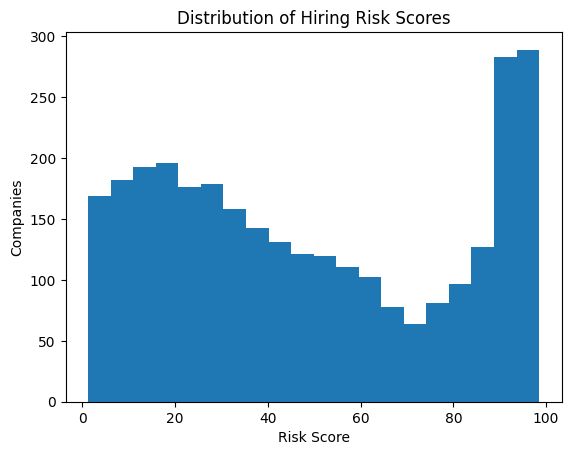

In [24]:
plt.hist(risk_df["Risk_Score"], bins=20)

plt.title("Distribution of Hiring Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Companies")

plt.show()

In [25]:
industry_risk = df.loc[X_test.index].copy()

industry_risk["risk_score"] = risk_score

In [27]:
# identify industry columns
industry_cols = [col for col in X.columns if col.startswith("industry_")]

# reconstruct industry name
industry_risk = X_test.copy()
industry_risk["risk_score"] = risk_score

industry_risk["industry"] = industry_risk[industry_cols].idxmax(axis=1)

industry_risk["industry"] = industry_risk["industry"].str.replace("industry_", "")

industry_risk.head()

,layoff_count,total_funding_million_usd,stock_price_change_7d,revenue_growth_percent,market_cap_billion_usd,ai_automation_flag,year,company_size_encoded,layoff_intensity,financial_stress,...,country_Brazil,country_Canada,country_Germany,country_India,country_Japan,country_Singapore,country_UK,country_USA,risk_score,industry
6537,324,468.33,-1.56,8.46,155.41,0,2026,2,2.071479,-6.90,...,False,False,True,False,False,False,False,False,83.520035,Tech
4886,45,104.91,-16.37,2.37,374.95,0,2021,0,0.119697,14.00,...,False,False,False,False,False,False,True,False,20.178595,Healthcare
10409,636,1856.77,-8.68,-9.81,467.19,0,2024,0,1.358423,18.49,...,False,True,False,False,False,False,False,False,96.038946,Energy
4900,318,1940.35,-2.25,23.13,491.35,0,2023,0,0.645882,-20.88,...,False,True,False,False,False,False,False,False,62.433097,EdTech
597,12,1654.58,2.96,-5.78,262.42,0,2021,0,0.045555,8.74,...,False,True,False,False,False,False,False,False,2.952069,EdTech


In [28]:
industry_rank = (
    industry_risk
    .groupby("industry")["risk_score"]
    .mean()
    .sort_values()
)

industry_rank

,risk_score
industry,
Energy,46.870279
EdTech,47.691052
Retail,48.852446
Healthcare,48.873377
Tech,48.936919
Finance,49.125700
FinTech,50.439195
Manufacturing,51.565337


In [29]:
industry_rank_df = industry_rank.reset_index()

industry_rank_df.columns = ["Industry", "Average_Risk"]

industry_rank_df["Stability_Rank"] = range(1, len(industry_rank_df) + 1)

industry_rank_df

,Industry,Average_Risk,Stability_Rank
0,Energy,46.870279,1
1,EdTech,47.691052,2
2,Retail,48.852446,3
3,Healthcare,48.873377,4
4,Tech,48.936919,5
5,Finance,49.125700,6
6,FinTech,50.439195,7
7,Manufacturing,51.565337,8


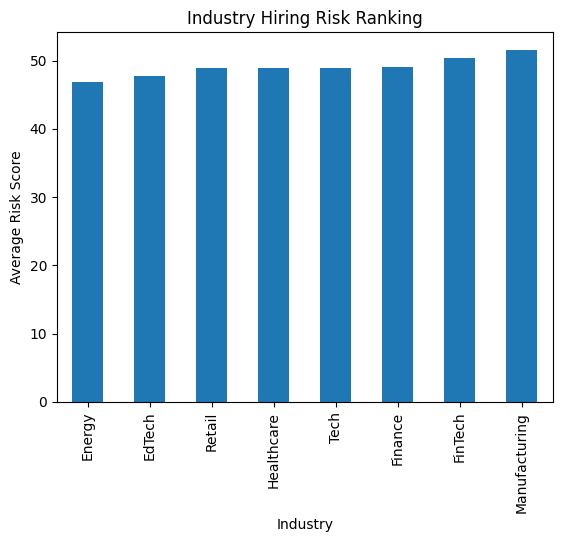

In [30]:
industry_rank.plot(kind="bar")

plt.title("Industry Hiring Risk Ranking")
plt.ylabel("Average Risk Score")
plt.xlabel("Industry")

plt.show()

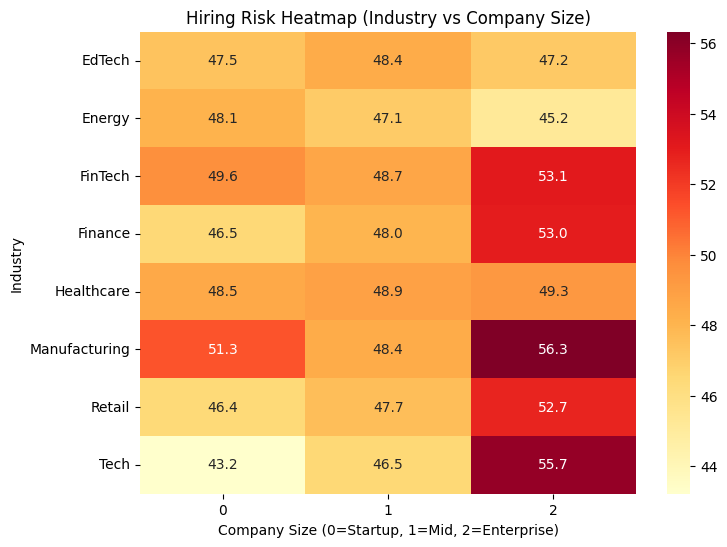

In [34]:
import seaborn as sns
# identify company size column
company_size = df.loc[X_test.index]["company_size_encoded"]

# rebuild industry again
industry_cols = [col for col in X.columns if col.startswith("industry_")]

heatmap_df = X_test.copy()

heatmap_df["risk_score"] = risk_score
heatmap_df["company_size"] = company_size

heatmap_df["industry"] = heatmap_df[industry_cols].idxmax(axis=1)
heatmap_df["industry"] = heatmap_df["industry"].str.replace("industry_", "")

# create pivot table
pivot_table = heatmap_df.pivot_table(
    values="risk_score",
    index="industry",
    columns="company_size",
    aggfunc="mean"
)

# plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap="YlOrRd",
    fmt=".1f"
)

plt.title("Hiring Risk Heatmap (Industry vs Company Size)")
plt.xlabel("Company Size (0=Startup, 1=Mid, 2=Enterprise)")
plt.ylabel("Industry")

plt.show()

In [31]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.677
              precision    recall  f1-score   support

      Freeze       0.61      0.59      0.60      1016
      Hiring       0.45      0.83      0.58       313
    Slowdown       0.82      0.70      0.75      1671

    accuracy                           0.68      3000
   macro avg       0.62      0.71      0.65      3000
weighted avg       0.71      0.68      0.68      3000



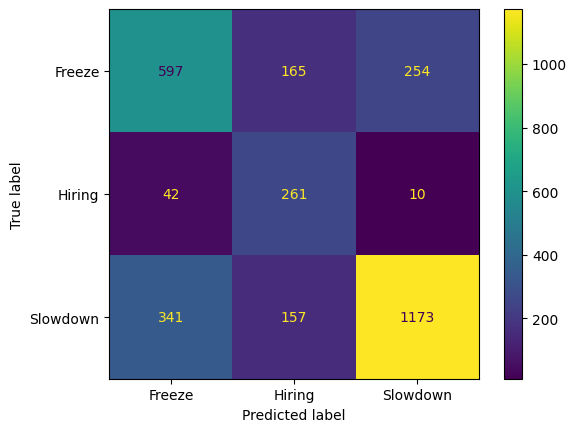

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

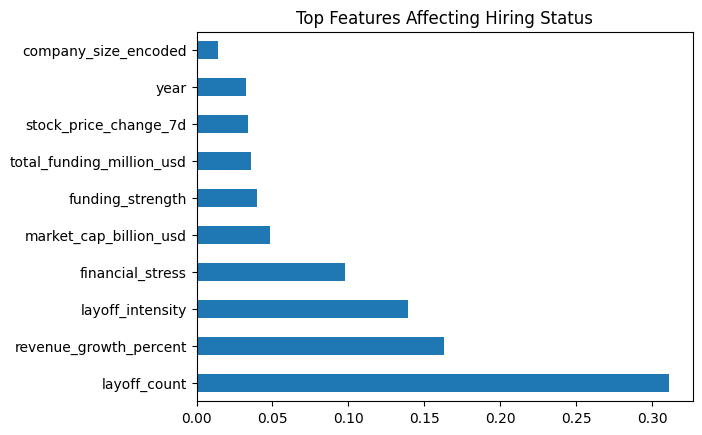

In [33]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.nlargest(10).plot(kind='barh')

plt.title("Top Features Affecting Hiring Status")
plt.show()

In [35]:
!pip install joblib

In [36]:
import joblib

# save trained model
joblib.dump(model, "hiresafe_model.pkl")

# save feature list
joblib.dump(X.columns.tolist(), "model_features.pkl")

print("Model saved successfully")

Model saved successfully
